# Historical notebook: pre-migration comparison

        Preserved during the PIRATE 1.5 migration, including its earlier assumptions,
        methods and outputs. It requires its matching older checkout/environment.
        For the current full-band workflow use the notebook with the same name
        one directory above. This historical copy is not validated on PIRATE 1.5.

# Inspecting PIRATE's four peak finders on one saved S/N map

This notebook is a self-contained, didactic inspection of the four current
peak finders in `peakfinder_tests.peakfinders`: **Bowtie banks**,
**Full-band bowtie**, **Hull**, and **Rectangle**. All four are applied to the
same saved `out_max` and `out_argmax` arrays from one tree. The reusable module
is the source of truth for candidate selection and decoding; notebook-local
geometry functions exist only to expose and verify the numerical construction.

The scope is deliberately narrow: no map simulation, benchmark, recall test,
separability test, or alternative peak-finding algorithm is run here.


In [324]:
from pathlib import Path

ASDF_PATH = Path(
    "/home/mtrudu/chordsim/repeater_dm100/frame_b100_t3_snrmap.asdf"
)
GPU_DEVICE = 0
TREE_INDEX = 0
SNR_THRESHOLD = 10.0

DM_REACH = 8
WAIST_BINS = 1
EDGE_POLICY = "exclude"

TIME_WINDOW_S = None
DM_WINDOW = None

DM_REACH_VALUES = [1, 2, 4, 8, 16]
MAX_TABLE_ROWS = 50


In [325]:
from pathlib import Path
import sys

repo_root = Path.cwd().parent
assert (repo_root / "pirate_frb").is_dir()
sys.path.insert(0, str(repo_root))

In [326]:
import pirate_frb
from pirate_frb import DedispersionPlan

print(pirate_frb.__file__)
print(hasattr(DedispersionPlan, "make_incomplete_plan_from_yaml"))

/home/mtrudu/src/pirate-updated/pirate_frb/__init__.py
True


## Load, reconstruct, and validate the saved product

Each saved tree is a two-dimensional `(coarse DM, coarse time)` map pair.
Validation is performed against the authoritative incomplete
`DedispersionPlan` reconstructed from the embedded `config_yaml` and
`plan_yaml`; no external configuration file is needed. Every tree is read on
the host to compute its summary statistics, but only the selected tree is
retained and later transferred to the GPU.

For each tree,

$$
\delta_{\rm DM}=\frac{{\rm DM}_{\max}-{\rm DM}_{\min}}{n_{\rm DM,out}},
\qquad
\delta_t=t_{\rm sample}\frac{n_{t,\rm in}}{n_{t,\rm out}}.
$$

`dm_reach` is an integer radius in these coarse DM-map bins, not a physical DM
interval. Its physical half-reach is `dm_reach * dm_step`, so the same integer
normally means a different physical reach in each tree. Likewise,
`waist_bins * time_step` is tree-dependent.


In [327]:
import html

import asdf
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, Normalize
import numpy as np
import yaml
from IPython.display import display

from pirate_frb import DedispersionPlan


class Table:
    # Keep notebook display independent of optional dataframe packages. Rows
    # remain ordinary dictionaries, so scientific values are not reformatted
    # or rounded before display.
    def __init__(self, rows=None, columns=None):
        self.rows = list(rows or [])
        self.columns = (
            list(columns) if columns is not None
            else (list(self.rows[0]) if self.rows else [])
        )

    def __len__(self):
        return len(self.rows)

    def head(self, number=5):
        return Table(self.rows[:number], self.columns)

    def _repr_html_(self):
        header = "".join(
            f"<th>{html.escape(str(column))}</th>" for column in self.columns
        )
        body = "".join(
            "<tr>" + "".join(
                f"<td>{html.escape(str(row.get(column, chr(160))))}</td>"
                for column in self.columns
            ) + "</tr>"
            for row in self.rows
        )
        return (
            "<div style='overflow-x:auto'><table><thead><tr>"
            f"{header}</tr></thead><tbody>{body}</tbody></table></div>"
        )


EXPECTED_FORMAT = "pirate_frb.offline_dedisperser_snr_maps"
EXPECTED_VERSION = 2

if EDGE_POLICY not in {"exclude", "include"}:
    raise ValueError("EDGE_POLICY must be 'exclude' or 'include'")
if not isinstance(DM_REACH, int) or DM_REACH < 0:
    raise ValueError("DM_REACH must be a non-negative integer map-bin radius")
if not isinstance(WAIST_BINS, int) or WAIST_BINS < 0:
    raise ValueError("WAIST_BINS must be a non-negative integer map-bin width")
if not DM_REACH_VALUES or any(not isinstance(value, int) or value < 0
                              for value in DM_REACH_VALUES):
    raise ValueError("DM_REACH_VALUES must contain non-negative integers")
if not ASDF_PATH.is_file():
    raise FileNotFoundError(ASDF_PATH)

with asdf.open(ASDF_PATH, lazy_load=True) as af:
    root = af.tree
    if root.get("format") != EXPECTED_FORMAT:
        raise ValueError(f"Unexpected ASDF format: {root.get('format')!r}")
    if int(root.get("format_version", -1)) != EXPECTED_VERSION:
        raise ValueError(
            f"Expected format_version={EXPECTED_VERSION}; "
            f"got {root.get('format_version')!r}"
        )

    config_yaml = str(root["config_yaml"])
    plan_yaml = str(root["plan_yaml"])
    config = yaml.safe_load(config_yaml)
    plan = DedispersionPlan.make_incomplete_plan_from_yaml(config_yaml, plan_yaml)
    source = dict(root["source"])
    time_sample_ms = float(root["time_sample_ms"])
    time_sample_s = time_sample_ms * 1.0e-3
    nt_in = int(root["nt_in"])
    nfreq = int(root["nfreq"])
    time_chunk_index = int(source["time_chunk_index"])

    zone_freq_edges = np.asarray(config["zone_freq_edges"], dtype=np.float64)
    if (zone_freq_edges.ndim != 1 or zone_freq_edges.size < 2
            or not np.all(np.diff(zone_freq_edges) > 0)):
        raise ValueError("Embedded zone_freq_edges must be a strictly increasing vector")
    reference_freq_mhz = float(zone_freq_edges[0])
    observing_freq_lo_mhz = float(zone_freq_edges[0])
    observing_freq_hi_mhz = float(zone_freq_edges[-1])

    trees = root["trees"]
    if len(trees) != len(plan.trees):
        raise ValueError(
            f"Saved tree count {len(trees)} != reconstructed plan count {len(plan.trees)}"
        )
    if not 0 <= TREE_INDEX < len(trees):
        raise IndexError(f"TREE_INDEX={TREE_INDEX}; file contains {len(trees)} trees")

    tree_rows = []
    snr_cpu = argmax_cpu = None
    for itree, (saved_tree, plan_tree) in enumerate(zip(trees, plan.trees)):
        if "snr" not in saved_tree or "argmax" not in saved_tree:
            raise ValueError(f"Tree {itree} does not contain both snr and argmax")

        snr_shape = tuple(saved_tree["snr"].shape)
        argmax_shape = tuple(saved_tree["argmax"].shape)
        expected_shape = (int(plan_tree.ndm_out), int(plan_tree.nt_out))
        if len(snr_shape) != 2 or len(argmax_shape) != 2:
            raise ValueError(
                f"Tree {itree} maps must be two-dimensional; "
                f"got snr={snr_shape}, argmax={argmax_shape}"
            )
        if snr_shape != argmax_shape:
            raise ValueError(
                f"Tree {itree} snr shape {snr_shape} != argmax shape {argmax_shape}"
            )
        if snr_shape != expected_shape:
            raise ValueError(
                f"Tree {itree} saved shape {snr_shape} != plan shape {expected_shape}"
            )
        if np.dtype(saved_tree["argmax"].dtype) != np.dtype(np.uint32):
            raise TypeError(
                f"Tree {itree} argmax dtype {saved_tree['argmax'].dtype} != uint32"
            )

        dm_min_i = float(plan_tree.dm_min)
        dm_max_i = float(plan_tree.dm_max)
        if not (np.isclose(float(saved_tree["dm_min"]), dm_min_i)
                and np.isclose(float(saved_tree["dm_max"]), dm_max_i)):
            raise ValueError(f"Tree {itree} saved DM bounds disagree with the plan")
        ndm_out_i, nt_out_i = expected_shape
        dm_step_i = (dm_max_i - dm_min_i) / ndm_out_i
        time_step_i_s = time_sample_s * nt_in / nt_out_i

        # Summary statistics require the saved S/N values, but no unselected
        # tree is uploaded to the GPU or retained after this loop iteration.
        tree_snr = np.asarray(saved_tree["snr"])
        tree_rows.append({
            "tree": itree,
            "DM minimum": dm_min_i,
            "DM maximum": dm_max_i,
            "ndm_out": ndm_out_i,
            "nt_out": nt_out_i,
            "DM step (pc cm^-3)": dm_step_i,
            "time step (ms)": time_step_i_s * 1.0e3,
            "maximum S/N": float(np.max(tree_snr)),
            f"cells > {SNR_THRESHOLD:g}": int(np.count_nonzero(tree_snr > SNR_THRESHOLD)),
            "DM_REACH * DM step (pc cm^-3)": DM_REACH * dm_step_i,
            "WAIST_BINS * time step (ms)": WAIST_BINS * time_step_i_s * 1.0e3,
        })

        if itree == TREE_INDEX:
            snr_cpu = np.array(tree_snr, copy=True)
            argmax_cpu = np.array(saved_tree["argmax"], dtype=np.uint32, copy=True)

if snr_cpu is None or argmax_cpu is None:
    raise AssertionError("Selected tree was not retained")
if snr_cpu.shape != argmax_cpu.shape or snr_cpu.ndim != 2:
    raise AssertionError("Selected maps lost their one-to-one two-dimensional shape")
if argmax_cpu.dtype != np.uint32:
    raise AssertionError("Selected argmax dtype changed during the host copy")

selected_tree = plan.trees[TREE_INDEX]
dm_min = float(selected_tree.dm_min)
dm_max = float(selected_tree.dm_max)
ndm_out = int(selected_tree.ndm_out)
nt_out = int(selected_tree.nt_out)
dm_step = (dm_max - dm_min) / ndm_out
time_step_s = time_sample_s * nt_in / nt_out

print(f"ASDF: {ASDF_PATH}")
print(
    f"beam={source['beam_id']}, time chunk={time_chunk_index}, "
    f"input={source['filename']}"
)
print(
    f"embedded observing band: {observing_freq_lo_mhz:g}--"
    f"{observing_freq_hi_mhz:g} MHz; reference={reference_freq_mhz:g} MHz"
)
print(
    f"selected tree {TREE_INDEX}: shape={snr_cpu.shape}, "
    f"DM step={dm_step:.9f} pc cm^-3, time step={time_step_s * 1e3:.6f} ms"
)
display(Table(tree_rows))


ASDF: /home/mtrudu/chordsim/repeater_dm100/frame_b100_t3_snrmap.asdf
beam=100, time chunk=3, input=/home/mtrudu/chordsim/repeater_dm100/frame_b100_t3.asdf
embedded observing band: 300--1500 MHz; reference=300 MHz
selected tree 0: shape=(4096, 128), DM step=0.473890332 pc cm^-3, time step=20.971520 ms


tree,DM minimum,DM maximum,ndm_out,nt_out,DM step (pc cm^-3),time step (ms),maximum S/N,cells > 10,DM_REACH * DM step (pc cm^-3),WAIST_BINS * time step (ms)
0,0.0,1941.054799354417,4096,128,0.47389033187363694,20.97152,37.125,184,3.7911226549890955,20.97152
1,1941.054799354417,3882.109598708834,2048,64,0.9477806637472739,41.94304,2.822265625,0,7.582245309978191,41.94304
2,3882.109598708834,7764.219197417668,2048,32,1.8955613274945478,83.88608,2.037109375,0,15.164490619956382,83.88608
3,7764.219197417668,15528.438394835335,2048,16,3.7911226549890955,167.77216,1.2373046875,0,30.328981239912764,167.77216


## Derivation of the basic bowtie

Let $X[i,j]$ be one saved S/N map, where $i$ is the coarse DM index and
$j$ is the coarse time index. For the selected tree define

$$
\delta_{\rm DM}=\frac{{\rm DM}_{\max}-{\rm DM}_{\min}}{n_{\rm DM,out}},
\qquad
\delta_t=t_{\rm sample}\frac{n_{t,\rm in}}{n_{t,\rm out}}.
$$

For `dm_reach = R`, the footprint visits row offsets
$k\in\{-R,\ldots,R\}$, with physical offsets
$\Delta{\rm DM}_k=k\,\delta_{\rm DM}$. For a searched interval
$[\nu_{\rm lo},\nu_{\rm hi}]$ and observing reference frequency
$\nu_{\rm ref}$, its continuous time edges in **output time-bin units** are

$$
a(k)=\frac{K_{\rm DM}\,\Delta{\rm DM}_k
(\nu_{\rm ref}^{-2}-\nu_{\rm lo}^{-2})}{\delta_t},
\qquad
b(k)=\frac{K_{\rm DM}\,\Delta{\rm DM}_k
(\nu_{\rm ref}^{-2}-\nu_{\rm hi}^{-2})}{\delta_t},
$$

where $K_{\rm DM}=4148.808\ {\rm s}$ when frequencies are in MHz and DM is
in pc cm$^{-3}$. First set

$$
\operatorname{lower}_0(k)=\min(a(k),b(k)),\qquad
\operatorname{upper}_0(k)=\max(a(k),b(k)).
$$

The current implementation uses an intentionally asymmetric waist convention.
For `w = waist_bins`,

$$
\operatorname{lower}(k)=
\begin{cases}
\operatorname{lower}_0(k)-w,&k<0\\
-w,&k=0\\
\operatorname{lower}_0(k),&k>0,
\end{cases}
\quad
\operatorname{upper}(k)=
\begin{cases}
\operatorname{upper}_0(k),&k<0\\
+w,&k=0\\
\operatorname{upper}_0(k)+w,&k>0.
\end{cases}
$$

An integer time offset $l$ is active exactly when
$\operatorname{lower}(k)\leq l\leq\operatorname{upper}(k)$. The allocated
time radius is symmetric,

$$
R_t=\left\lceil\max\left(-\min_k\operatorname{lower}(k),
\max_k\operatorname{upper}(k)\right)\right\rceil,
$$

and membership is evaluated for every integer $l\in[-R_t,R_t]$. Thus:

- `dm_reach` controls the coarse DM rows on either side of the centre, for
  `2 * dm_reach + 1` total rows and physical half-reach
  `dm_reach * delta_DM`;
- increasing `dm_reach` also increases the footprint's temporal extent through
  the dispersion-delay slopes;
- `waist_bins` is measured in output time bins and has physical duration
  `waist_bins * delta_t`;
- both parameters have different physical meanings in different trees; and
- discretization can make physically different sub-band bowties collapse to
  exactly the same boolean mask.


## The four local-maximum geometries

For a centred footprint $F$, all four methods use the same condition at centre
$p$:

$$
X[p] > T,\qquad X[p]=\max_{q\in p+F}X[q].
$$

The threshold comparison is strict. Equality with the local maximum is not
strict, so distinct equal-valued tied maxima may survive. With
`EDGE_POLICY="exclude"`, `maximum_filter` supplies $+\infty$ outside the map;
therefore any centre whose active footprint crosses a map boundary cannot equal
its filtered maximum and is rejected.

### 1. Bowtie banks

The centre pixel's `argmax` token identifies its multiplet and hence its winning
searched frequency interval. **Only the centre token selects the footprint.**
Neighbour tokens neither select nor modify that centre's footprint, although
all neighbouring S/N values still come from the common `out_max` map. Continuous
intervals can discretize to identical masks, so the bank is deduplicated by
exact boolean-mask equality before filtering.

### 2. Full-band bowtie

This method filters with the bowtie generated directly from the one uniquely
decoded full observing interval: `geometry.full_band_footprint`. The centred
union of all bank masks is retained only as an invariant check. For this plan it
must equal the directly generated full-band footprint; the union is not the
filtering operation.

### 3. Hull

The Hull contains every lattice cell inside or on the discrete convex hull of
the active full-band-bowtie offsets. It fills concave regions while preserving
the smallest convex discrete geometry that contains the full-band bowtie.

### 4. Rectangle

The Rectangle is the smallest centred, axis-aligned, all-True rectangle that
contains the full-band bowtie. Its DM and time radii are the maximum absolute
active offsets of that source footprint.

The intended footprint containment is

$$
F_{\rm subband}\subseteq F_{\rm full}\subseteq F_{\rm hull}
\subseteq F_{\rm rectangle},
$$

and the centred union of every sub-band bowtie equals $F_{\rm full}$. A larger
maximum-filter footprint can only keep the same number or fewer centres, so the
candidate containment reverses:

$$
C_{\rm rectangle}\subseteq C_{\rm hull}\subseteq C_{\rm full}
\subseteq C_{\rm banks}.
$$


In [328]:
import peakfinder_tests.peakfinders as pf

if tuple(pf.METHODS) != (
    "bowtie_banks", "full_band_bowtie", "hull", "rectangle"
):
    raise RuntimeError(f"Unexpected current methods: {pf.METHODS}")

with cp.cuda.Device(GPU_DEVICE):
    geometry = pf.build_peakfinder_geometry(
        plan,
        TREE_INDEX,
        time_sample_s=time_sample_s,
        nt_in=nt_in,
        reference_freq_mhz=reference_freq_mhz,
        dm_reach=DM_REACH,
        waist_bins=WAIST_BINS,
    )

assert geometry.ndm == ndm_out and geometry.nt == nt_out
assert np.isclose(geometry.dm_step, dm_step)
assert np.isclose(geometry.time_step_s, time_step_s)
print(
    f"Current module geometry: {len(geometry.subbands)} decoded intervals, "
    f"{len(geometry.unique_footprints)} exactly unique bowties"
)


Current module geometry: 25 decoded intervals, 25 exactly unique bowties


## Explained geometry generators: bowties, exact deduplication, and union

The following `_explained` functions reproduce the current module's numerical
geometry logic for inspection only. They are never used to select or decode
candidates. Comments focus on how physical offsets become centred discrete
masks and why exact operations are used.


In [329]:
K_DM_EXPLAINED = 4148.808


def make_subband_bowtie_gpu_explained(
        dm_reach, dm_step, time_step_s, freq_lo_mhz, freq_hi_mhz,
        reference_freq_mhz, waist_bins):
    '''Construct one searched interval's discrete bowtie on the GPU.'''
    if dm_reach < 0 or waist_bins < 0:
        raise ValueError("Bowtie reach and waist must be non-negative")
    if not reference_freq_mhz <= freq_lo_mhz < freq_hi_mhz:
        raise ValueError("Invalid reference/sub-band frequency ordering")

    # These are physical DM offsets from the candidate centre. Their spacing
    # is the selected tree's coarse DM-map step, not 1 pc cm^-3.
    dm_offsets = (
        cp.arange(-dm_reach, dm_reach + 1, dtype=cp.float64) * dm_step
    )

    # Each band edge supplies a dispersion-delay slope relative to the
    # observing reference frequency. Dividing by the tree's output time step
    # expresses both continuous edges in coarse output-bin coordinates.
    slope_lo = K_DM_EXPLAINED * (
        reference_freq_mhz**-2 - freq_lo_mhz**-2
    )
    slope_hi = K_DM_EXPLAINED * (
        reference_freq_mhz**-2 - freq_hi_mhz**-2
    )
    edge_a = dm_offsets * slope_lo / time_step_s
    edge_b = dm_offsets * slope_hi / time_step_s
    lower = cp.minimum(edge_a, edge_b)
    upper = cp.maximum(edge_a, edge_b)

    # The waist extends the later-time edge for positive DM offsets and the
    # earlier-time edge for negative offsets. The central row explicitly spans
    # [-waist_bins, +waist_bins], matching the asymmetric convention derived
    # above rather than applying a symmetric dilation to every row.
    upper[dm_offsets > 0] += waist_bins
    lower[dm_offsets < 0] -= waist_bins
    lower[dm_offsets == 0] = -waist_bins
    upper[dm_offsets == 0] = waist_bins

    # A symmetric radius produces an odd number of columns with a unique
    # central time cell. Some allocated edge cells may remain False; allocation
    # and physical membership are intentionally separate.
    time_reach = int(
        cp.ceil(cp.maximum(-lower.min(), upper.max())).item()
    )
    time_offsets = cp.arange(
        -time_reach, time_reach + 1, dtype=cp.int32
    )
    return (
        (time_offsets[None, :] >= lower[:, None])
        & (time_offsets[None, :] <= upper[:, None])
    )


def deduplicate_bowtie_bank_gpu_explained(footprints):
    '''Remove exact duplicate masks while retaining every interval mapping.'''
    unique_footprints, unique_cpu, unique_to_bands = [], [], []
    band_to_unique = np.empty(len(footprints), dtype=np.int32)
    fingerprint_buckets = {}
    for band, footprint_gpu in enumerate(footprints):
        footprint_cpu = np.ascontiguousarray(
            cp.asnumpy(footprint_gpu), dtype=np.bool_
        )

        # Shape plus packed boolean bits is an exact fingerprint candidate.
        # The subsequent array_equal check makes collisions harmless: no
        # geometrically distinct mask is merged by tolerance or summary value.
        fingerprint = (
            footprint_cpu.shape,
            np.packbits(footprint_cpu.reshape(-1)).tobytes(),
        )
        matched_unique = None
        for unique_index in fingerprint_buckets.get(fingerprint, []):
            candidate = unique_cpu[unique_index]
            if (candidate.shape == footprint_cpu.shape
                    and np.array_equal(candidate, footprint_cpu)):
                matched_unique = unique_index
                break
        if matched_unique is None:
            matched_unique = len(unique_footprints)
            unique_footprints.append(footprint_gpu)
            unique_cpu.append(footprint_cpu)
            unique_to_bands.append([])
            fingerprint_buckets.setdefault(fingerprint, []).append(
                matched_unique
            )
        band_to_unique[band] = matched_unique
        unique_to_bands[matched_unique].append(band)
    return unique_footprints, band_to_unique, unique_to_bands


def _require_odd_centered_footprint_explained(footprint, name):
    if (footprint.ndim != 2
            or any(size < 1 or size % 2 == 0 for size in footprint.shape)):
        raise ValueError(
            f"{name} must be non-empty, 2-D and odd-shaped; got {footprint.shape}"
        )


def make_union_bowtie_gpu_explained(footprints):
    '''Return a minimally cropped centred union for invariant checking.'''
    if not footprints:
        raise ValueError("At least one footprint is required")
    for index, footprint in enumerate(footprints):
        _require_odd_centered_footprint_explained(
            footprint, f"footprint {index}"
        )

    # Different bands can have different time radii. Padding them onto a common
    # centred grid before OR-ing preserves the meaning of every (delta DM,
    # delta time) cell; top-left alignment would shift smaller footprints.
    dm_radius = max(footprint.shape[0] // 2 for footprint in footprints)
    time_radius = max(footprint.shape[1] // 2 for footprint in footprints)
    union = cp.zeros(
        (2 * dm_radius + 1, 2 * time_radius + 1), dtype=cp.bool_
    )
    for footprint in footprints:
        radius_dm = footprint.shape[0] // 2
        radius_time = footprint.shape[1] // 2
        dm_start = dm_radius - radius_dm
        time_start = time_radius - radius_time
        union[
            dm_start:dm_start + footprint.shape[0],
            time_start:time_start + footprint.shape[1],
        ] |= footprint

    active_dm, active_time = cp.nonzero(union)
    if active_dm.size == 0:
        raise ValueError("Union footprint is empty")

    # Symmetric cropping retains an odd shape and the same physical centre even
    # if the outer allocated rows or columns contain no active cells.
    radius_dm = int(cp.max(cp.abs(active_dm - dm_radius)).item())
    radius_time = int(cp.max(cp.abs(active_time - time_radius)).item())
    return union[
        dm_radius - radius_dm:dm_radius + radius_dm + 1,
        time_radius - radius_time:time_radius + radius_time + 1,
    ]


## Explained geometry generators: integer hull and bounding rectangle

Active cells are represented by integer `(delta time, delta DM)` coordinates.
Integer cross products make orientation and boundary tests exact, avoiding a
floating-point tolerance in the discrete convex-hull construction.


In [330]:
def _cross_explained(origin, a, b):
    '''Signed twice-area: positive means an anticlockwise turn.'''
    return (
        (a[0] - origin[0]) * (b[1] - origin[1])
        - (a[1] - origin[1]) * (b[0] - origin[0])
    )


def _convex_hull_vertices_integer_explained(points):
    '''Return strict boundary vertices with the monotone-chain algorithm.'''
    points = sorted(set(tuple(map(int, point)) for point in points))
    if len(points) <= 1:
        return points

    # Collinear points between endpoints do not define new hull edges. Removing
    # them here leaves the smallest ordered vertex list for exact half-plane
    # membership tests below.
    lower = []
    for point in points:
        while (len(lower) >= 2
               and _cross_explained(lower[-2], lower[-1], point) <= 0):
            lower.pop()
        lower.append(point)
    upper = []
    for point in reversed(points):
        while (len(upper) >= 2
               and _cross_explained(upper[-2], upper[-1], point) <= 0):
            upper.pop()
        upper.append(point)
    return lower[:-1] + upper[:-1]


def _inside_or_on_convex_hull_explained(point, hull):
    '''Test exact integer membership, including every hull boundary.'''
    if len(hull) == 1:
        return point == hull[0]
    if len(hull) == 2:
        return (
            _cross_explained(hull[0], hull[1], point) == 0
            and min(hull[0][0], hull[1][0])
            <= point[0] <= max(hull[0][0], hull[1][0])
            and min(hull[0][1], hull[1][1])
            <= point[1] <= max(hull[0][1], hull[1][1])
        )
    return all(
        _cross_explained(hull[index], hull[(index + 1) % len(hull)], point)
        >= 0
        for index in range(len(hull))
    )


def make_convex_hull_bowtie_gpu_explained(source_footprint):
    '''Fill every lattice centre inside/on the source mask's convex hull.'''
    _require_odd_centered_footprint_explained(
        source_footprint, "source footprint"
    )
    source_cpu = np.ascontiguousarray(
        cp.asnumpy(source_footprint), dtype=np.bool_
    )
    center_dm, center_time = np.asarray(source_cpu.shape) // 2

    # Subtracting the unique array centre converts active array indices to the
    # centred integer geometry used by all footprint containment statements.
    points = [
        (int(itime - center_time), int(idm - center_dm))
        for idm, itime in np.argwhere(source_cpu)
    ]
    hull_vertices = _convex_hull_vertices_integer_explained(points)
    hull_cpu = np.zeros_like(source_cpu)
    for idm in range(source_cpu.shape[0]):
        for itime in range(source_cpu.shape[1]):
            hull_cpu[idm, itime] = _inside_or_on_convex_hull_explained(
                (itime - center_time, idm - center_dm), hull_vertices
            )
    if not np.all(hull_cpu[source_cpu]):
        raise AssertionError("Discrete convex hull lost an active source cell")
    return cp.asarray(hull_cpu), hull_vertices


def make_bowtie_bounding_rectangle_gpu_explained(source_footprint):
    '''Return the minimal centred all-True rectangle around active cells.'''
    _require_odd_centered_footprint_explained(
        source_footprint, "source footprint"
    )
    active_dm, active_time = cp.nonzero(source_footprint)
    center_dm, center_time = (
        size // 2 for size in source_footprint.shape
    )

    # Maximum absolute active offsets are the smallest symmetric radii that
    # retain the centred full-band geometry on each axis.
    radius_dm = int(cp.max(cp.abs(active_dm - center_dm)).item())
    radius_time = int(cp.max(cp.abs(active_time - center_time)).item())
    return cp.ones(
        (2 * radius_dm + 1, 2 * radius_time + 1), dtype=cp.bool_
    )


## Exact reproduction and footprint-containment checks

This cell independently regenerates the explanatory masks, then requires exact
shape and cell equality with the current reusable module. A discrepancy raises
an error at the first named geometry; it is never repaired by altering the
module from inside this notebook.


In [331]:
def assert_same_mask(name, explained, current):
    if explained.shape != current.shape:
        raise AssertionError(
            f"{name}: explained shape {explained.shape} != current {current.shape}"
        )
    if not bool(cp.array_equal(explained, current).item()):
        different = int(cp.count_nonzero(explained != current).item())
        raise AssertionError(f"{name}: {different} boolean cells differ")


with cp.cuda.Device(GPU_DEVICE):
    explained_original = [
        make_subband_bowtie_gpu_explained(
            DM_REACH,
            dm_step,
            time_step_s,
            band.freq_lo_MHz,
            band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for band in geometry.subbands
    ]
    current_original = [
        pf.make_subband_bowtie_gpu(
            DM_REACH,
            dm_step,
            time_step_s,
            band.freq_lo_MHz,
            band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for band in geometry.subbands
    ]
    for band, explained, current in zip(
            geometry.subbands, explained_original, current_original):
        assert_same_mask(band.subband_id, explained, current)

    explained_unique, explained_band_to_unique, explained_unique_to_bands = (
        deduplicate_bowtie_bank_gpu_explained(explained_original)
    )
    if not np.array_equal(
            explained_band_to_unique, cp.asnumpy(geometry.band_to_unique)):
        raise AssertionError("Explained band-to-unique mapping differs from the module")
    if tuple(tuple(group) for group in explained_unique_to_bands) != geometry.unique_to_bands:
        raise AssertionError("Explained unique-to-band mapping differs from the module")
    if len(explained_unique) != len(geometry.unique_footprints):
        raise AssertionError("Explained unique-bank size differs from the module")
    for unique_index, (explained, current) in enumerate(
            zip(explained_unique, geometry.unique_footprints)):
        assert_same_mask(f"unique bowtie {unique_index}", explained, current)

    explained_full = explained_original[geometry.full_band_index]
    assert_same_mask(
        "direct full-band bowtie", explained_full, geometry.full_band_footprint
    )
    explained_union = make_union_bowtie_gpu_explained(explained_original)
    current_union = pf.make_union_bowtie_gpu(current_original)
    assert_same_mask("centred union (explained/current)", explained_union, current_union)
    assert_same_mask("centred union/direct full band", explained_union, explained_full)

    explained_hull, explained_hull_vertices = (
        make_convex_hull_bowtie_gpu_explained(explained_full)
    )
    assert_same_mask("Hull", explained_hull, geometry.hull_footprint)
    if tuple(explained_hull_vertices) != geometry.hull_vertices:
        raise AssertionError("Explained integer hull vertices differ from the module")

    explained_rectangle = make_bowtie_bounding_rectangle_gpu_explained(
        explained_full
    )
    assert_same_mask("Rectangle", explained_rectangle, geometry.rectangle_footprint)


def checked_offsets(name, footprint):
    if footprint.ndim != 2 or any(
            size < 1 or size % 2 == 0 for size in footprint.shape):
        raise AssertionError(f"{name} is not non-empty, 2-D, and odd-shaped")
    center = tuple(size // 2 for size in footprint.shape)
    if not bool(footprint[center].item()):
        raise AssertionError(f"{name} does not contain its central cell")
    return pf.centered_active_offsets_cpu(footprint)


full_offsets = checked_offsets("Full-band bowtie", geometry.full_band_footprint)
subband_offsets = []
for band, footprint in zip(geometry.subbands, current_original):
    offsets = checked_offsets(band.subband_id, footprint)
    if not offsets <= full_offsets:
        raise AssertionError(f"{band.subband_id} is not a centred full-band subset")
    subband_offsets.append(offsets)
for unique_index, footprint in enumerate(geometry.unique_footprints):
    checked_offsets(f"unique bowtie {unique_index}", footprint)
union_offsets = checked_offsets("centred union", explained_union)
hull_offsets = checked_offsets("Hull", geometry.hull_footprint)
rectangle_offsets = checked_offsets("Rectangle", geometry.rectangle_footprint)

if union_offsets != full_offsets:
    raise AssertionError("Centred union is not exactly the direct full-band bowtie")
if not full_offsets <= hull_offsets <= rectangle_offsets:
    raise AssertionError("Expected Full-band subset Hull subset Rectangle")

geometry_reproduction_passed = True
footprint_containment_passed = True
print("PASS: notebook-local generators exactly reproduce every module geometry.")
print("PASS: all footprint shape, centre, union, and containment checks hold.")


PASS: notebook-local generators exactly reproduce every module geometry.
PASS: all footprint shape, centre, union, and containment checks hold.


## Every unique Bowtie-bank footprint

There is no representative bank footprint: each centre selects the mask for its
own winning interval. The table maps every exactly unique mask back to all
decoded intervals that use it. Each plotted cell has physical size
`dm_step` by `time_step`; the red open marker identifies the central cell.


unique footprint,stable sub-band ID,fmin,fmax,frequency interval (MHz),hierarchy level,order within level,full observing band,mask shape,active cells
0,f0_4095,0,4095,948.683298--1500,0,0,False,"(17, 19)",29
1,f4096_8191,4096,8191,750--948.683298,0,1,False,"(17, 19)",21
2,f8192_12287,8192,12287,639.602149--750,0,2,False,"(17, 17)",25
3,f12288_16383,12288,16383,566.94671--639.602149,0,3,False,"(17, 17)",25
4,f16384_20479,16384,20479,514.495755--566.94671,0,4,False,"(17, 15)",21
5,f0_8191,0,8191,750--1500,1,0,False,"(17, 19)",31
6,f4096_12287,4096,12287,639.602149--948.683298,1,1,False,"(17, 19)",25
7,f8192_16383,8192,16383,566.94671--750,1,2,False,"(17, 17)",31
8,f12288_20479,12288,20479,514.495755--639.602149,1,3,False,"(17, 17)",27
9,f16384_24575,16384,24575,474.341649--566.94671,1,4,False,"(17, 15)",25


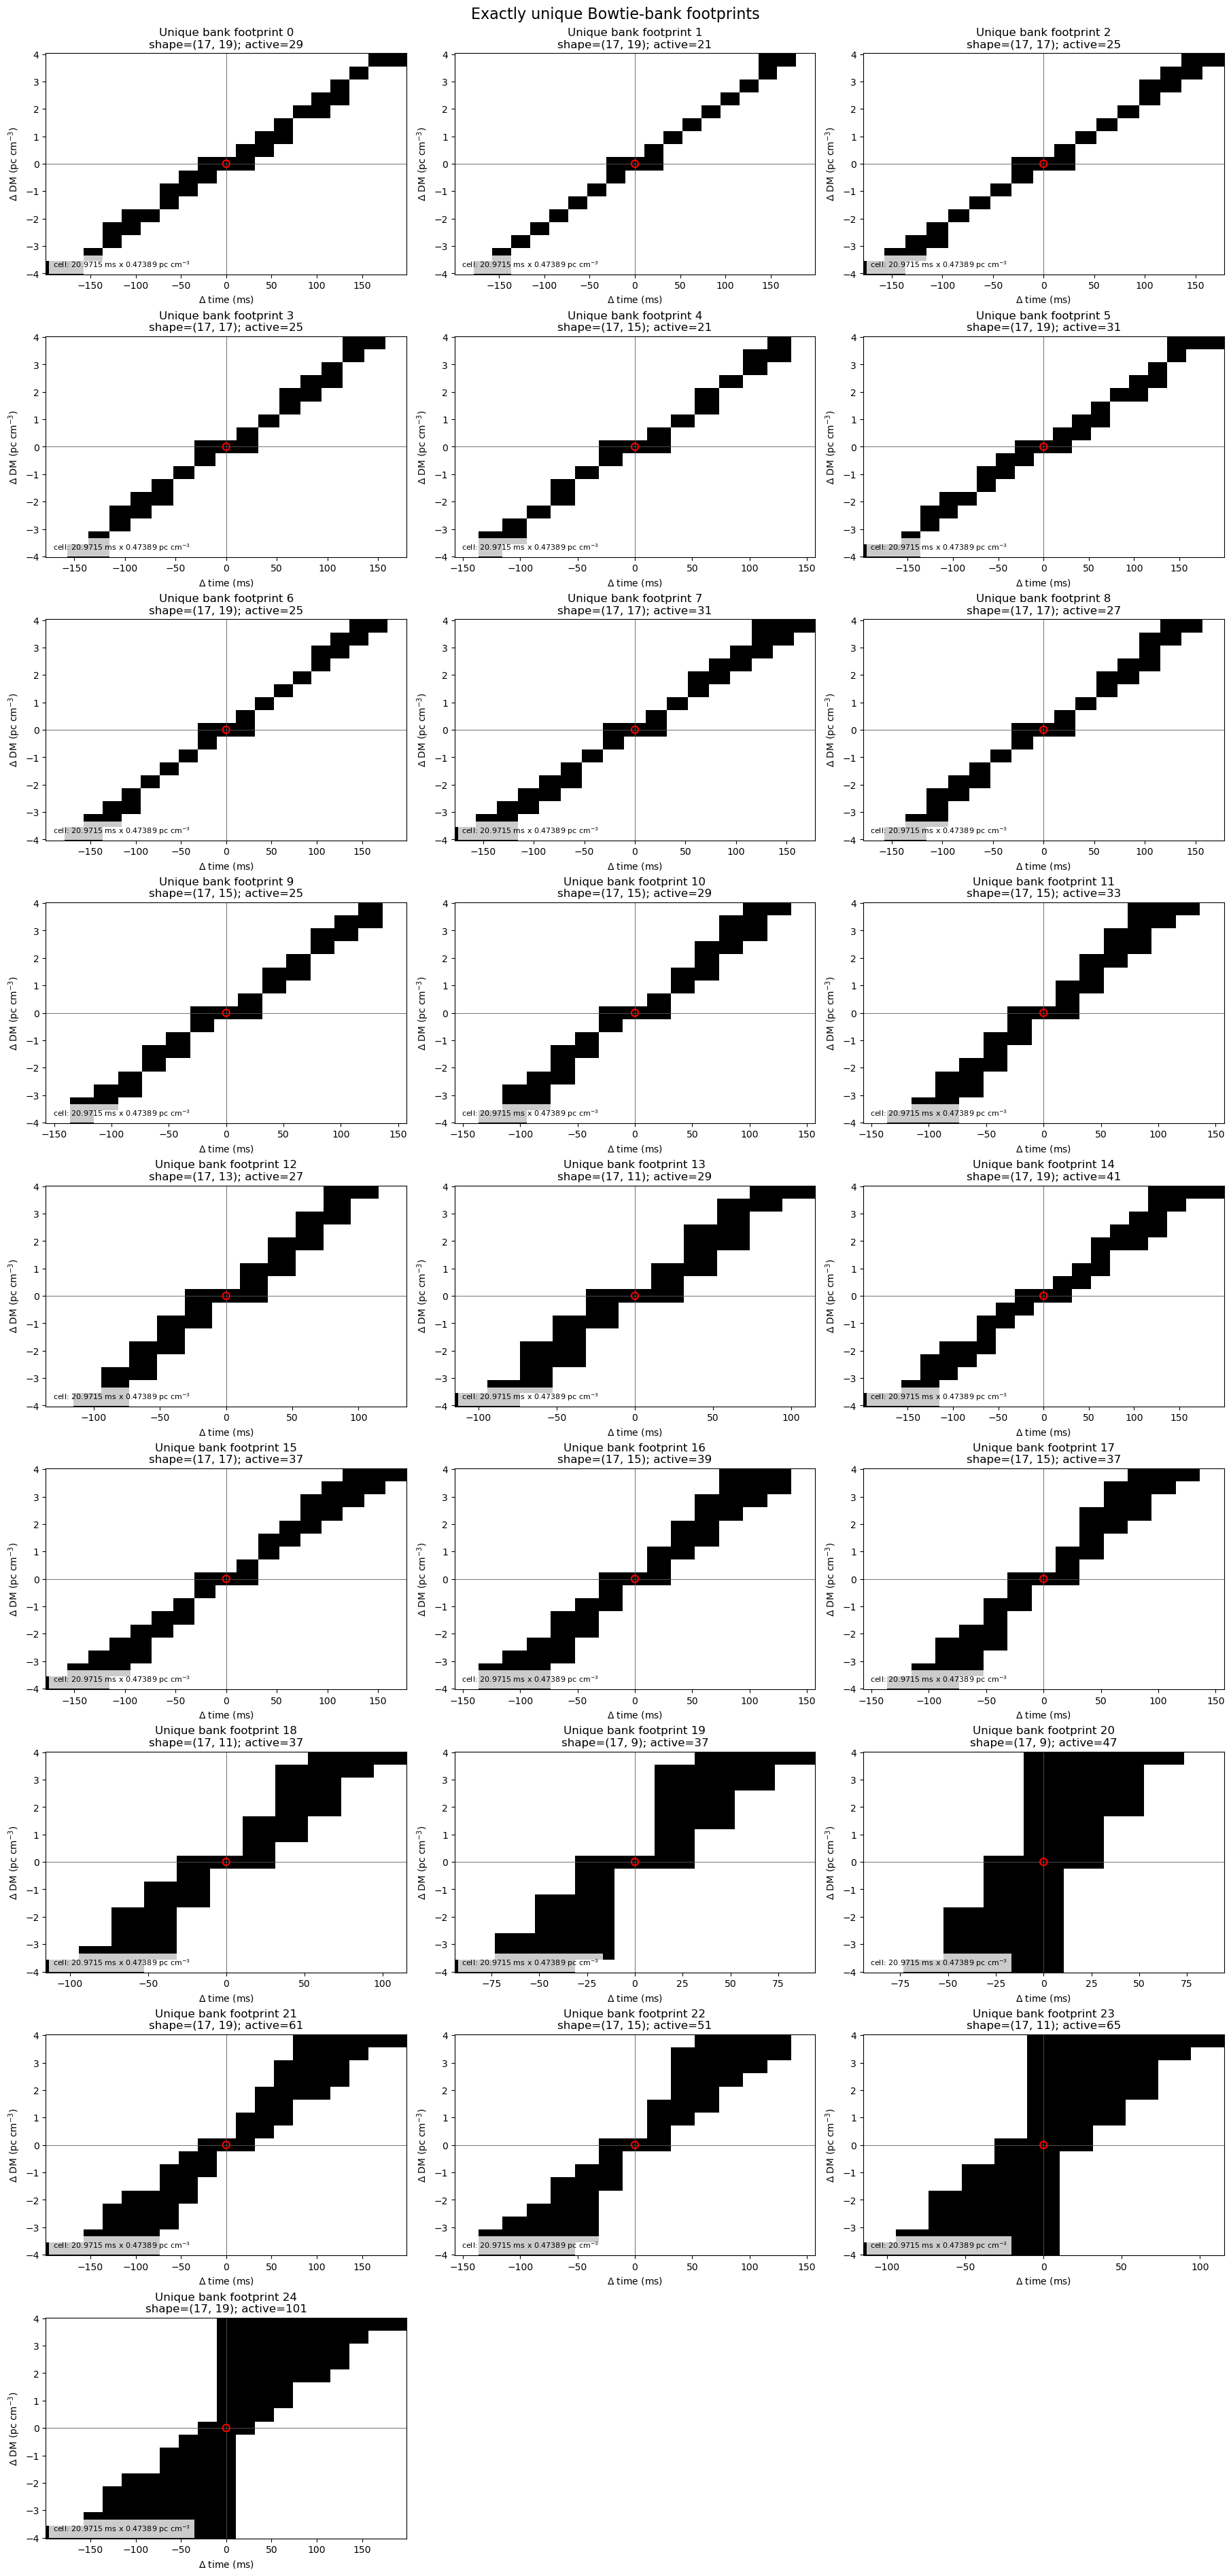

In [332]:
def footprint_stats_cpu(footprint):
    mask = np.ascontiguousarray(cp.asnumpy(footprint), dtype=np.bool_)
    return mask, int(np.count_nonzero(mask))


bank_mapping_rows = []
for unique_index, band_indices in enumerate(geometry.unique_to_bands):
    footprint = geometry.unique_footprints[unique_index]
    _, active_cells = footprint_stats_cpu(footprint)
    for band_index in band_indices:
        band = geometry.subbands[band_index]
        bank_mapping_rows.append({
            "unique footprint": unique_index,
            "stable sub-band ID": band.subband_id,
            "fmin": band.fmin,
            "fmax": band.fmax,
            "frequency interval (MHz)": (
                f"{band.freq_lo_MHz:.9g}--{band.freq_hi_MHz:.9g}"
            ),
            "hierarchy level": band.level,
            "order within level": band.order_within_level,
            "full observing band": band.is_full_band,
            "mask shape": str(tuple(footprint.shape)),
            "active cells": active_cells,
        })

bank_mapping_table = Table(bank_mapping_rows)
display(bank_mapping_table)


FOOTPRINT_CMAP = ListedColormap(["white", "black"])


def plot_footprint_physical(ax, footprint, title, *, xlim=None, ylim=None):
    mask, active_cells = footprint_stats_cpu(footprint)
    radius_dm, radius_time = np.asarray(mask.shape) // 2
    time_edges_ms = (
        np.arange(-radius_time - 0.5, radius_time + 1.5) * time_step_s * 1.0e3
    )
    dm_edges_physical = (
        np.arange(-radius_dm - 0.5, radius_dm + 1.5) * dm_step
    )
    ax.pcolormesh(
        time_edges_ms,
        dm_edges_physical,
        mask.astype(np.int8),
        cmap=FOOTPRINT_CMAP,
        vmin=0,
        vmax=1,
        shading="flat",
        edgecolors="0.85" if mask.size <= 300 else "none",
        linewidth=0.0,
    )
    ax.scatter(
        [0.0], [0.0], marker="o", facecolors="none", edgecolors="red",
        linewidths=1.5, s=55, zorder=3,
    )
    ax.axhline(0.0, color="0.35", linewidth=0.6)
    ax.axvline(0.0, color="0.35", linewidth=0.6)
    ax.set(
        title=f"{title}\nshape={mask.shape}; active={active_cells}",
        xlabel=r"$\Delta$ time (ms)",
        ylabel=r"$\Delta$ DM (pc cm$^{-3}$)",
    )
    ax.text(
        0.02,
        0.02,
        f"cell: {time_step_s * 1e3:.6g} ms x {dm_step:.6g} pc cm$^{{-3}}$",
        transform=ax.transAxes,
        fontsize=8,
        va="bottom",
        bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
    )
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)


nunique = len(geometry.unique_footprints)
ncols = min(3, nunique)
nrows = int(np.ceil(nunique / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(6 * ncols, 4.2 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(-1)
for unique_index, footprint in enumerate(geometry.unique_footprints):
    plot_footprint_physical(
        axes[unique_index], footprint, f"Unique bank footprint {unique_index}"
    )
for ax in axes[nunique:]:
    ax.set_visible(False)
fig.suptitle("Exactly unique Bowtie-bank footprints", fontsize=16)
plt.show()


## Full-band bowtie, Hull, and Rectangle

These are the three fixed footprints used by the corresponding methods. Their
panels share identical physical limits, making the filled concavities and the
bounding rectangle directly comparable. The centred bank union is not shown as
a fourth method because it is only an invariant and is exactly equal to the
direct full-band mask.


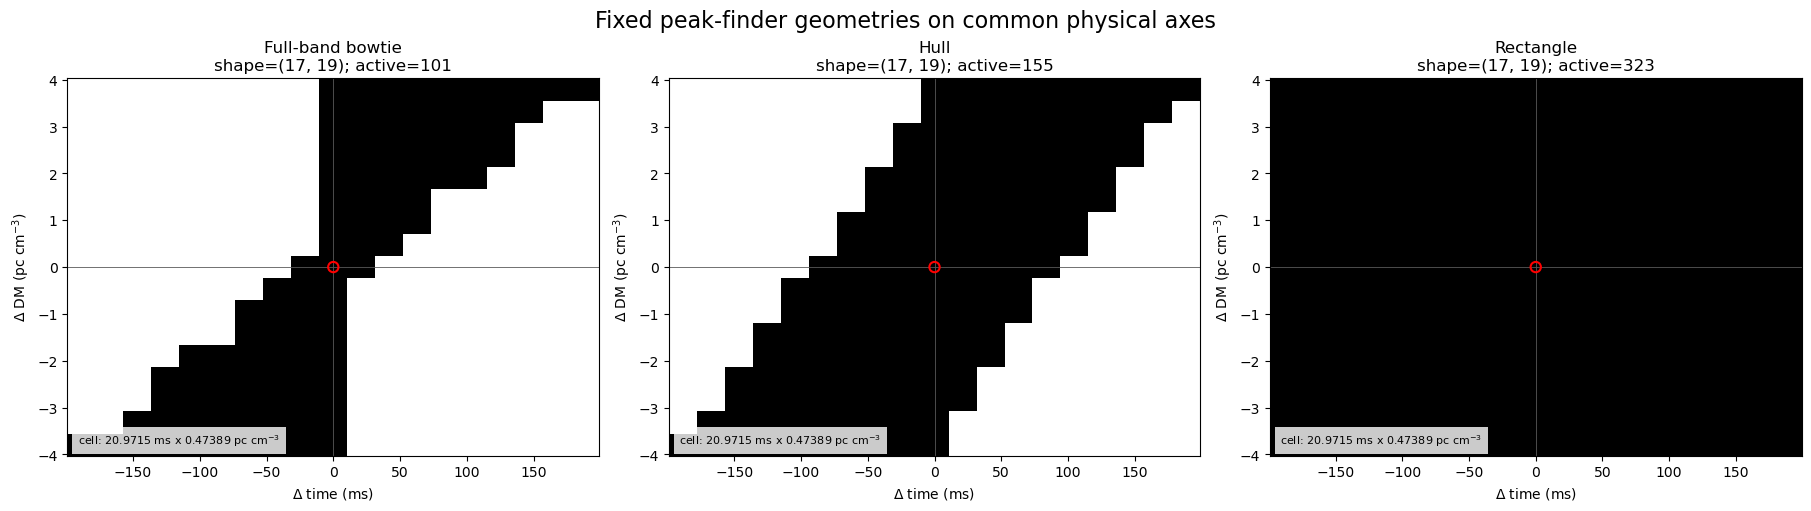

In [333]:
fixed_footprints = [
    ("Full-band bowtie", geometry.full_band_footprint),
    ("Hull", geometry.hull_footprint),
    ("Rectangle", geometry.rectangle_footprint),
]
max_dm_radius = max(footprint.shape[0] // 2 for _, footprint in fixed_footprints)
max_time_radius = max(footprint.shape[1] // 2 for _, footprint in fixed_footprints)
common_footprint_xlim = (
    -(max_time_radius + 0.5) * time_step_s * 1.0e3,
    +(max_time_radius + 0.5) * time_step_s * 1.0e3,
)
common_footprint_ylim = (
    -(max_dm_radius + 0.5) * dm_step,
    +(max_dm_radius + 0.5) * dm_step,
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
for ax, (name, footprint) in zip(axes, fixed_footprints):
    plot_footprint_physical(
        ax,
        footprint,
        name,
        xlim=common_footprint_xlim,
        ylim=common_footprint_ylim,
    )
fig.suptitle("Fixed peak-finder geometries on common physical axes", fontsize=16)
plt.show()


## What `dm_reach` changes

This is a map-grid parameter. For each requested value below, the current
module regenerates the selected tree's **direct full-band** bowtie while keeping
`WAIST_BINS` fixed. The number of rows is `2 * dm_reach + 1`, and the physical
half-reach is `dm_reach * dm_step` -- not `dm_reach` pc cm$^{-3}$.


dm_reach,number of DM rows,physical DM half-reach (pc cm^-3),mask shape,maximum |time| reach (bins),maximum |time| reach (ms),active cells,mask occupancy
1,3,0.47389033187363694,"(3, 5)",2,41.94304,9,0.6
2,5,0.9477806637472739,"(5, 7)",3,62.91456000000001,17,0.4857142857142857
4,9,1.8955613274945478,"(9, 11)",5,104.85759999999999,37,0.37373737373737376
8,17,3.7911226549890955,"(17, 19)",9,188.74367999999998,101,0.3126934984520124
16,33,7.582245309978191,"(33, 35)",17,356.51584,325,0.2813852813852814


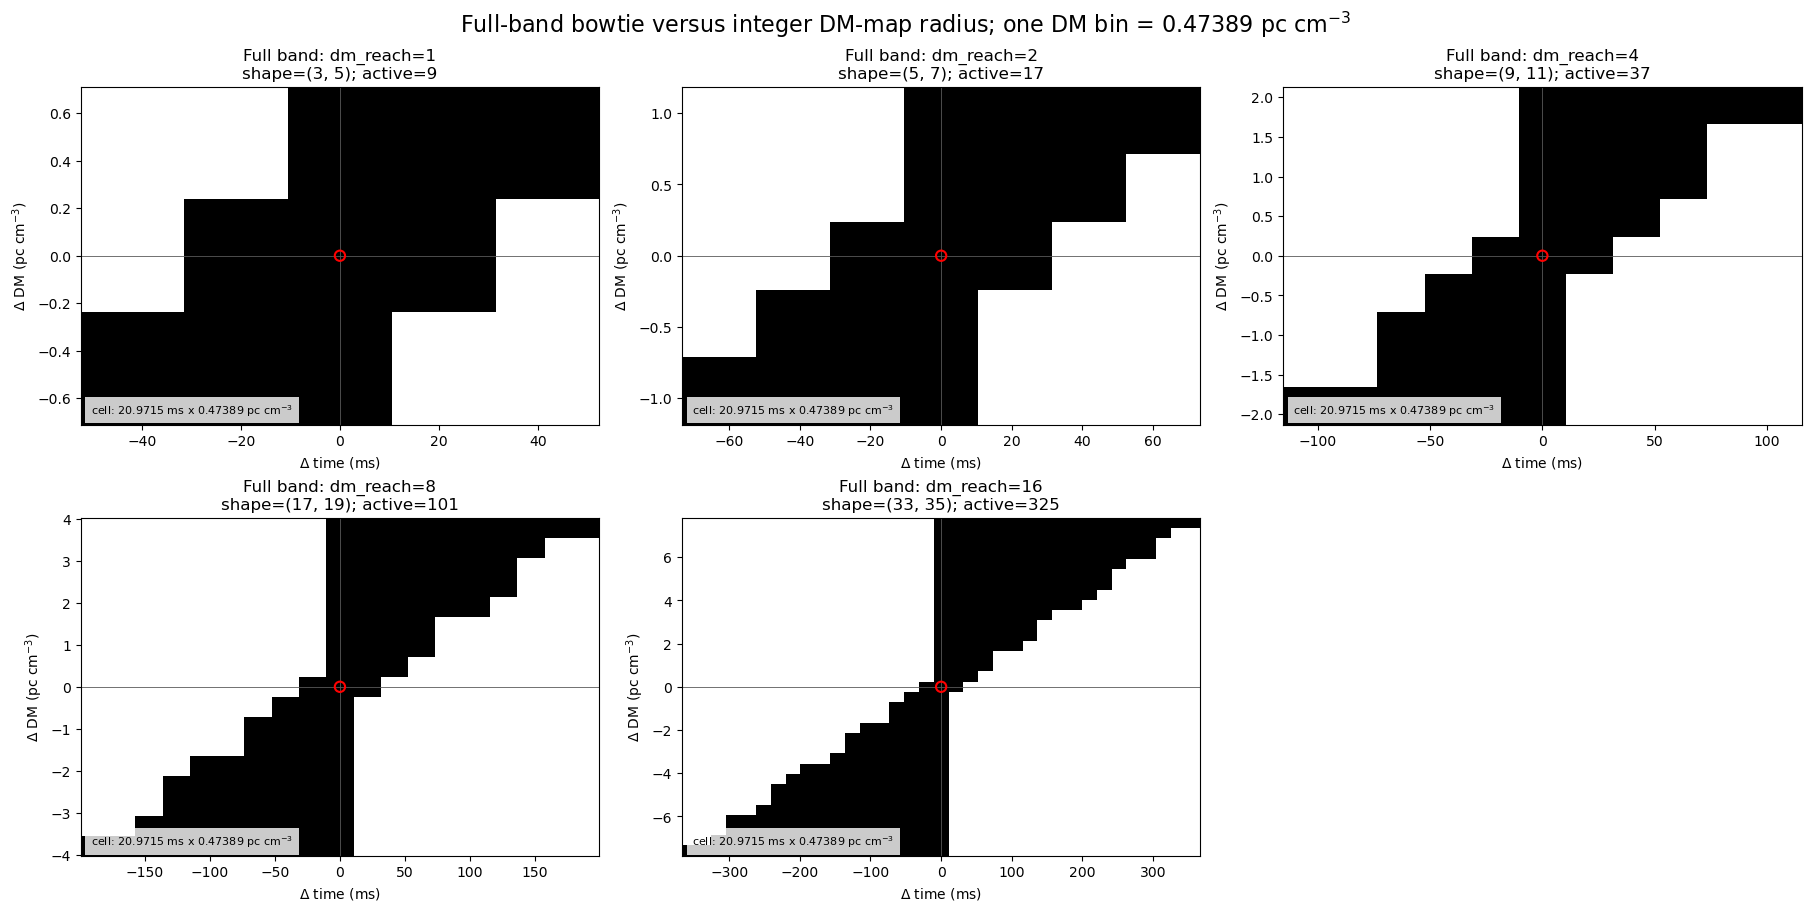

In [334]:
full_band = geometry.subbands[geometry.full_band_index]
with cp.cuda.Device(GPU_DEVICE):
    reach_footprints = {
        reach: pf.make_subband_bowtie_gpu(
            reach,
            dm_step,
            time_step_s,
            full_band.freq_lo_MHz,
            full_band.freq_hi_MHz,
            reference_freq_mhz,
            WAIST_BINS,
        )
        for reach in DM_REACH_VALUES
    }

reach_rows = []
for reach, footprint in reach_footprints.items():
    mask, active_cells = footprint_stats_cpu(footprint)
    center = np.asarray(mask.shape) // 2
    active = np.argwhere(mask)
    max_time_reach_bins = int(np.max(np.abs(active[:, 1] - center[1])))
    reach_rows.append({
        "dm_reach": reach,
        "number of DM rows": 2 * reach + 1,
        "physical DM half-reach (pc cm^-3)": reach * dm_step,
        "mask shape": str(mask.shape),
        "maximum |time| reach (bins)": max_time_reach_bins,
        "maximum |time| reach (ms)": max_time_reach_bins * time_step_s * 1.0e3,
        "active cells": active_cells,
        "mask occupancy": active_cells / mask.size,
    })

reach_table = Table(reach_rows)
display(reach_table)

nreach = len(reach_footprints)
ncols = min(3, nreach)
nrows = int(np.ceil(nreach / ncols))
fig, axes = plt.subplots(
    nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), constrained_layout=True
)
axes = np.atleast_1d(axes).reshape(-1)
for ax, (reach, footprint) in zip(axes, reach_footprints.items()):
    plot_footprint_physical(ax, footprint, f"Full band: dm_reach={reach}")
for ax in axes[nreach:]:
    ax.set_visible(False)
fig.suptitle(
    f"Full-band bowtie versus integer DM-map radius; "
    f"one DM bin = {dm_step:.6g} pc cm$^{{-3}}$",
    fontsize=16,
)
plt.show()


## Apply the four current methods to the saved `t3` map

The selected host arrays now cross to the selected GPU exactly once. One
`PeakFinderGeometry` and the same `snr_gpu` and `argmax_gpu` objects are passed
to all four calls. Candidate selection is exclusively through
`pf.run_peakfinder`; decoding is exclusively through `pf.decode_candidates`.


In [335]:
with cp.cuda.Device(GPU_DEVICE):
    snr_gpu = cp.asarray(snr_cpu)
    argmax_gpu = cp.asarray(argmax_cpu)

if snr_gpu.shape != argmax_gpu.shape:
    raise AssertionError("GPU S/N and argmax shapes disagree")
if snr_gpu.shape != (geometry.ndm, geometry.nt):
    raise AssertionError("GPU maps disagree with the current geometry")
if argmax_gpu.dtype != cp.uint32:
    raise AssertionError("GPU argmax dtype is not uint32")

input_pointers = {}
candidates_by_method = {}
with cp.cuda.Device(GPU_DEVICE):
    for method in pf.METHODS:
        input_pointers[method] = (int(snr_gpu.data.ptr), int(argmax_gpu.data.ptr))
        candidates_by_method[method] = pf.run_peakfinder(
            method,
            snr_gpu,
            argmax_gpu,
            geometry,
            SNR_THRESHOLD,
            edge_policy=EDGE_POLICY,
        )

if len(set(input_pointers.values())) != 1:
    raise AssertionError("The four methods did not receive the same GPU map objects")

candidate_containment_passed = pf.validate_candidate_set_containment(
    candidates_by_method,
    context=f"{ASDF_PATH.name}, tree {TREE_INDEX}",
)
candidate_counts = {
    method: len(candidates_by_method[method]) for method in pf.METHODS
}

decoded_by_method = {
    method: pf.decode_candidates(
        plan,
        candidates,
        itree=TREE_INDEX,
        time_chunk_index=time_chunk_index,
        ntime=nt_in,
        time_sample_s=time_sample_s,
    )
    for method, candidates in candidates_by_method.items()
}

print("Candidate counts:")
for method in pf.METHODS:
    print(f"  {pf.METHOD_LABELS[method]}: {candidate_counts[method]}")
print("PASS: candidate-coordinate containment holds.")


Candidate counts:
  Bowtie banks: 5
  Full-band bowtie: 3
  Hull: 3
  Rectangle: 1
PASS: candidate-coordinate containment holds.


## Full-band Bowtie sensitivity to `dm_reach`

This supplemental experiment applies only the **Full-band Bowtie** peak finder
to the same GPU-resident maps for `dm_reach = [1, 2, 4, 8, 16, 32]`, with all
other settings fixed. Each timing is the median of 10 synchronized CUDA-event
measurements after one warm-up call; geometry construction and candidate decoding
are excluded. The summary shows whether candidates disappear as the footprint grows,
and the second table reports every surviving candidate at every reach.


In [336]:
FULL_BAND_REACH_VALUES = [1, 2, 4, 8, 16, 32]
FULL_BAND_TIMING_REPEATS = 10

full_band_reach_results = {}
with cp.cuda.Device(GPU_DEVICE):
    for reach in FULL_BAND_REACH_VALUES:
        reach_geometry = pf.build_peakfinder_geometry(
            plan,
            TREE_INDEX,
            time_sample_s=time_sample_s,
            nt_in=nt_in,
            reference_freq_mhz=reference_freq_mhz,
            dm_reach=reach,
            waist_bins=WAIST_BINS,
        )

        # Warm up this footprint shape before collecting synchronized GPU timings.
        pf.run_peakfinder(
            "full_band_bowtie", snr_gpu, argmax_gpu, reach_geometry,
            SNR_THRESHOLD, edge_policy=EDGE_POLICY,
        )
        cp.cuda.get_current_stream().synchronize()

        elapsed_ms = []
        for _ in range(FULL_BAND_TIMING_REPEATS):
            start_event = cp.cuda.Event()
            stop_event = cp.cuda.Event()
            start_event.record()
            candidates = pf.run_peakfinder(
                "full_band_bowtie", snr_gpu, argmax_gpu, reach_geometry,
                SNR_THRESHOLD, edge_policy=EDGE_POLICY,
            )
            stop_event.record()
            stop_event.synchronize()
            elapsed_ms.append(cp.cuda.get_elapsed_time(start_event, stop_event))

        full_band_reach_results[reach] = {
            "geometry": reach_geometry,
            "candidates": candidates,
            "elapsed_ms": np.asarray(elapsed_ms, dtype=np.float64),
        }

full_band_reach_summary_rows = []
full_band_reach_candidate_rows = []
previous_coordinates = None
for reach in FULL_BAND_REACH_VALUES:
    result = full_band_reach_results[reach]
    reach_geometry = result["geometry"]
    candidates = result["candidates"]
    coordinates = pf.candidate_coordinate_set(candidates)
    removed = None if previous_coordinates is None else len(previous_coordinates - coordinates)
    added = None if previous_coordinates is None else len(coordinates - previous_coordinates)
    footprint = reach_geometry.full_band_footprint
    full_band_reach_summary_rows.append({
        "dm_reach": reach,
        "footprint shape": str(tuple(footprint.shape)),
        "active footprint cells": int(cp.count_nonzero(footprint).item()),
        "detected candidates": len(candidates),
        "removed vs previous reach": removed,
        "added vs previous reach": added,
        "median execution time (ms)": float(np.median(result["elapsed_ms"])),
    })

    decoded = pf.decode_candidates(
        plan, candidates, itree=TREE_INDEX,
        time_chunk_index=time_chunk_index, ntime=nt_in,
        time_sample_s=time_sample_s,
    )
    for rank in range(len(candidates)):
        full_band_reach_candidate_rows.append({
            "dm_reach": reach,
            "rank": rank + 1,
            "S/N": float(decoded["snr"][rank]),
            "coarse idm": int(decoded["idm"][rank]),
            "coarse itime": int(decoded["itime"][rank]),
            "decoded DM (pc cm^-3)": float(decoded["dm"][rank]),
            "decoded TOA (s)": float(decoded["toa_ref_s"][rank]),
        })
    previous_coordinates = coordinates

display(Table(full_band_reach_summary_rows))
display(Table(full_band_reach_candidate_rows))


dm_reach,footprint shape,active footprint cells,detected candidates,removed vs previous reach,added vs previous reach,median execution time (ms)
1,"(3, 5)",9,6,None,None,0.4373439997434616
2,"(5, 7)",17,3,3,0,0.4418559968471527
4,"(9, 11)",37,3,0,0,0.4336159974336624
8,"(17, 19)",101,3,0,0,0.5581119954586029
16,"(33, 35)",325,3,0,0,0.9477440118789673
32,"(65, 67)",1159,3,0,0,2.4755200147628784


dm_reach,rank,S/N,coarse idm,coarse itime,decoded DM (pc cm^-3),decoded TOA (s)
1,1,37.125,210,51,99.7660933375912,9.144507552894641
1,2,20.453125,211,45,100.00306743102966,9.000328992972776
1,3,15.515625,211,59,100.00306743102966,9.299828512972777
1,4,10.21875,234,65,111.14084982263724,9.4106144366451
1,5,10.1484375,188,42,89.339233226299,8.907239069456722
1,6,10.078125,236,66,112.08874619639107,9.431588516957637
2,1,37.125,210,51,99.7660933375912,9.144507552894641
2,2,20.453125,211,45,100.00306743102966,9.000328992972776
2,3,15.515625,211,59,100.00306743102966,9.299828512972777
4,1,37.125,210,51,99.7660933375912,9.144507552894641


## Final map-level result

The background in every panel is the same original S/N map with the same
normalization and physical coarse-cell edges. Only final surviving candidates
are overlaid, as open markers at their **decoded physical DM** and **decoded
reference-frequency TOA**.

The map edges account for the nonzero chunk index:

```python
dm_edges = dm_min + arange(ndm_out + 1) * dm_step
chunk_start_s = time_chunk_index * nt_in * time_sample_s
time_edges = chunk_start_s + arange(nt_out + 1) * time_step_s
```


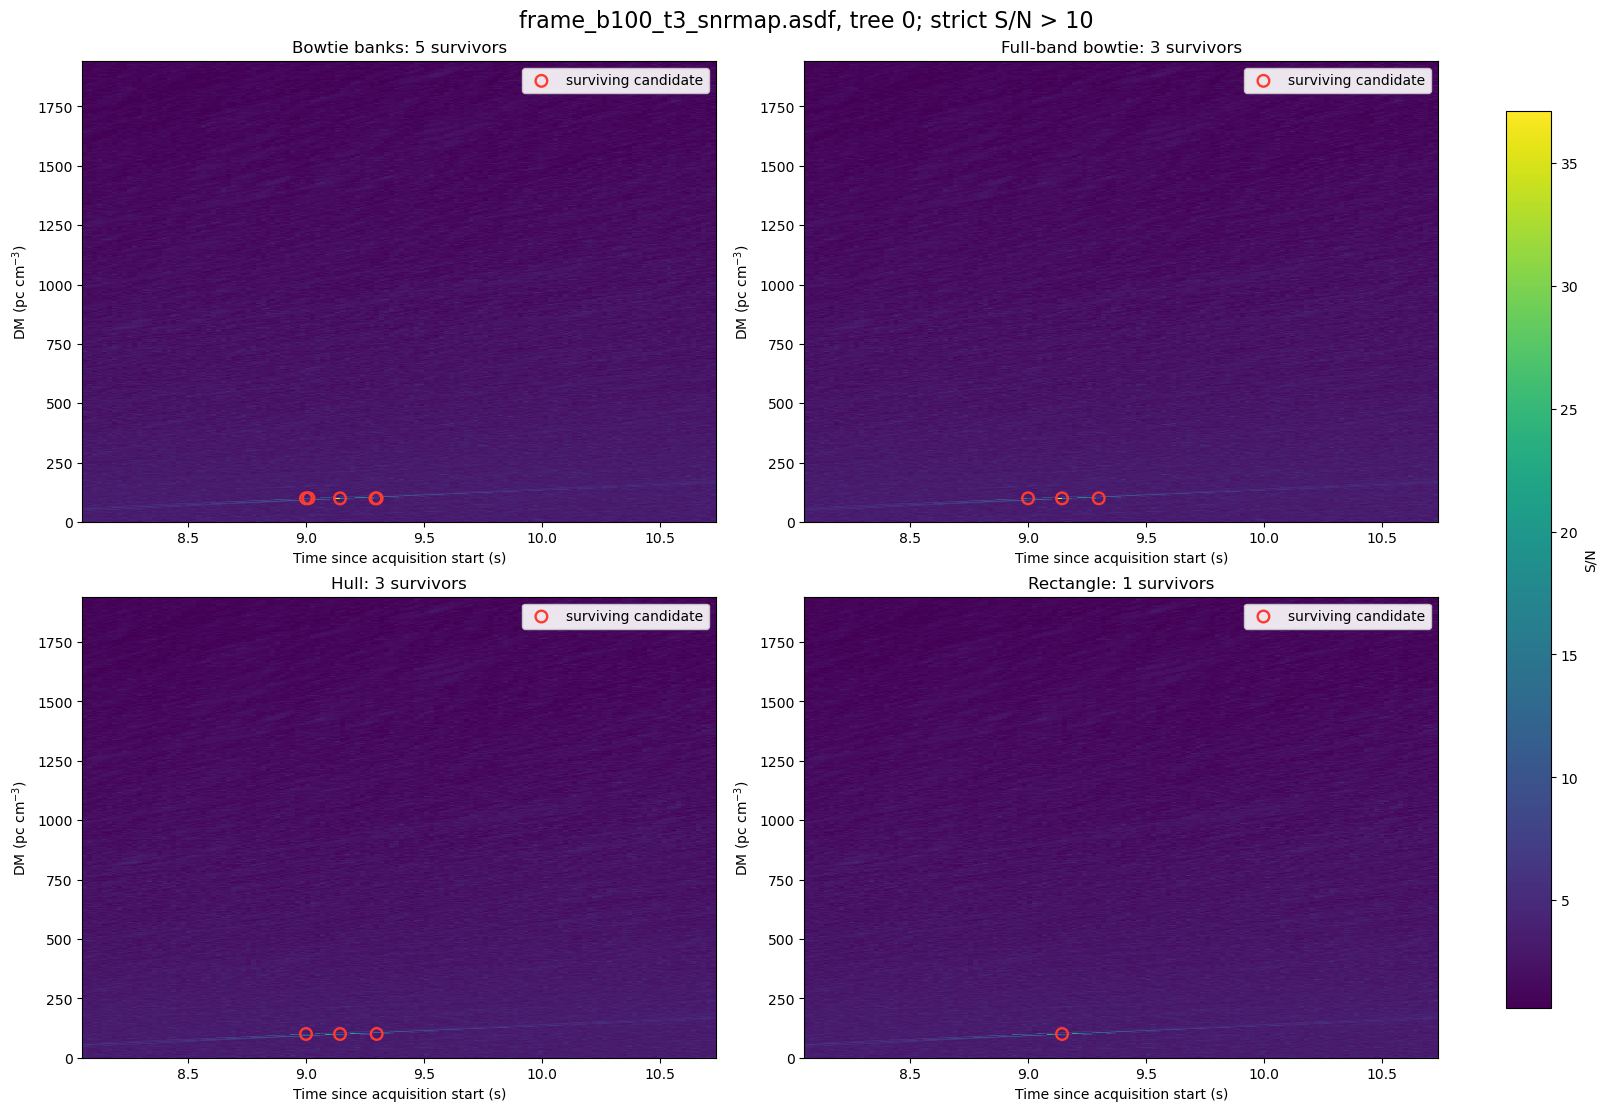

In [337]:
dm_edges = dm_min + np.arange(ndm_out + 1) * dm_step
chunk_start_s = time_chunk_index * nt_in * time_sample_s
time_edges = chunk_start_s + np.arange(nt_out + 1) * time_step_s

if TIME_WINDOW_S is None:
    common_time_limits = (float(time_edges[0]), float(time_edges[-1]))
else:
    if len(TIME_WINDOW_S) != 2 or not TIME_WINDOW_S[0] < TIME_WINDOW_S[1]:
        raise ValueError("TIME_WINDOW_S must be None or an increasing pair")
    common_time_limits = tuple(map(float, TIME_WINDOW_S))

if DM_WINDOW is None:
    common_dm_limits = (float(dm_edges[0]), float(dm_edges[-1]))
else:
    if len(DM_WINDOW) != 2 or not DM_WINDOW[0] < DM_WINDOW[1]:
        raise ValueError("DM_WINDOW must be None or an increasing pair")
    common_dm_limits = tuple(map(float, DM_WINDOW))

if not (np.all(np.isfinite(snr_cpu))
        and np.all(np.isfinite(dm_edges))
        and np.all(np.isfinite(time_edges))
        and np.all(np.isfinite(common_time_limits))
        and np.all(np.isfinite(common_dm_limits))):
    raise AssertionError("A plotted map value or physical edge is non-finite")

for method, decoded in decoded_by_method.items():
    for field in ("snr", "dm", "toa_ref_s", "width_s", "freq_lo_MHz", "freq_hi_MHz"):
        if not np.all(np.isfinite(decoded[field])):
            raise AssertionError(f"{method}: decoded field {field} is non-finite")

snr_norm = Normalize(
    vmin=float(np.percentile(snr_cpu, 1.0)),
    vmax=float(np.max(snr_cpu)),
)
fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
axes = axes.reshape(-1)
for ax, method in zip(axes, pf.METHODS):
    image = ax.pcolormesh(
        time_edges,
        dm_edges,
        snr_cpu,
        cmap="viridis",
        norm=snr_norm,
        shading="flat",
        rasterized=True,
    )
    decoded = decoded_by_method[method]
    ax.scatter(
        decoded["toa_ref_s"],
        decoded["dm"],
        marker="o",
        facecolors="none",
        edgecolors="#ff3b30",
        linewidths=1.7,
        s=70,
        zorder=3,
        label="surviving candidate",
    )
    ax.set(
        title=f"{pf.METHOD_LABELS[method]}: {candidate_counts[method]} survivors",
        xlabel="Time since acquisition start (s)",
        ylabel=r"DM (pc cm$^{-3}$)",
        xlim=common_time_limits,
        ylim=common_dm_limits,
    )
    ax.legend(loc="upper right", framealpha=0.9)

colorbar = fig.colorbar(image, ax=axes.tolist(), shrink=0.9)
colorbar.set_label("S/N")
fig.suptitle(
    f"{ASDF_PATH.name}, tree {TREE_INDEX}; strict S/N > {SNR_THRESHOLD:g}",
    fontsize=16,
)
plt.show()

all_plotted_physical_values_finite = True


### Timestamp and sub-cell coordinate convention

`pf.decode_candidates` uses PIRATE's `decode_argmax_batch` and
`decode_argmax2_batch`; it does not approximate physical parameters from coarse
cell centres. `toa_ref_s` is the arrival time at the embedded observing
reference frequency (here derived from the first `zone_freq_edges` value), in
seconds since the beginning of the acquisition. The decoder's in-chunk sample
timestamp is converted with `time_sample_s`, then offset by
`time_chunk_index * nt_in * time_sample_s`.

A marker need not lie exactly at its coarse map cell centre. `out_max` and
`out_argmax` retain the winning fine DM/time trial inside each coarse output
cell, so the decoded coordinate is more specific than `(idm, itime)` alone.


In [338]:
candidate_rows = []
for method in pf.METHODS:
    decoded = decoded_by_method[method]
    for index in range(decoded["snr"].size):
        candidate_rows.append({
            "method": method,
            "S/N": float(decoded["snr"][index]),
            "coarse idm": int(decoded["idm"][index]),
            "coarse itime": int(decoded["itime"][index]),
            "decoded DM (pc cm^-3)": float(decoded["dm"][index]),
            "decoded TOA since acquisition start (s)": float(decoded["toa_ref_s"][index]),
            "decoded width (ms)": float(decoded["width_s"][index]) * 1.0e3,
            "profile": int(decoded["profile"][index]),
            "fmin": int(decoded["fmin"][index]),
            "fmax": int(decoded["fmax"][index]),
            "winning frequency lower edge (MHz)": float(decoded["freq_lo_MHz"][index]),
            "winning frequency upper edge (MHz)": float(decoded["freq_hi_MHz"][index]),
            "argmax token": int(decoded["argmax_token"][index]),
            "_method_order": pf.METHODS.index(method),
        })

candidate_columns = [
    "method", "S/N", "coarse idm", "coarse itime",
    "decoded DM (pc cm^-3)", "decoded TOA since acquisition start (s)",
    "decoded width (ms)", "profile", "fmin", "fmax",
    "winning frequency lower edge (MHz)",
    "winning frequency upper edge (MHz)", "argmax token",
]
candidate_rows.sort(key=lambda row: (row["_method_order"], -row["S/N"]))
candidate_table = Table(
    [
        {column: row[column] for column in candidate_columns}
        for row in candidate_rows
    ],
    candidate_columns,
)
display(candidate_table.head(MAX_TABLE_ROWS))
if len(candidate_table) > MAX_TABLE_ROWS:
    print(
        f"Displayed {MAX_TABLE_ROWS} of {len(candidate_table)} rows; "
        "increase MAX_TABLE_ROWS in the parameter cell to see more."
    )


method,S/N,coarse idm,coarse itime,decoded DM (pc cm^-3),decoded TOA since acquisition start (s),decoded width (ms),profile,fmin,fmax,winning frequency lower edge (MHz),winning frequency upper edge (MHz),argmax token
bowtie_banks,37.125,210,51,99.7660933375912,9.144507552894641,3.9321600000000005,3,28672,36863,393.9192985791677,442.32586846469144,1311502
bowtie_banks,20.453125,211,45,100.00306743102966,9.000328992972776,2.62144,2,28672,36863,393.9192985791677,442.32586846469144,1245699
bowtie_banks,19.625,212,45,100.47701561790659,9.010816033129045,2.62144,2,28672,36863,393.9192985791677,442.32586846469144,1245707
bowtie_banks,15.515625,211,59,100.00306743102966,9.299828512972777,3.9321600000000005,3,28672,36863,393.9192985791677,442.32586846469144,1245960
bowtie_banks,15.296875,210,59,99.7660933375912,9.294584992894642,2.62144,2,28672,36863,393.9192985791677,442.32586846469144,1311232
full_band_bowtie,37.125,210,51,99.7660933375912,9.144507552894641,3.9321600000000005,3,28672,36863,393.9192985791677,442.32586846469144,1311502
full_band_bowtie,20.453125,211,45,100.00306743102966,9.000328992972776,2.62144,2,28672,36863,393.9192985791677,442.32586846469144,1245699
full_band_bowtie,15.515625,211,59,100.00306743102966,9.299828512972777,3.9321600000000005,3,28672,36863,393.9192985791677,442.32586846469144,1245960
hull,37.125,210,51,99.7660933375912,9.144507552894641,3.9321600000000005,3,28672,36863,393.9192985791677,442.32586846469144,1311502
hull,20.453125,211,45,100.00306743102966,9.000328992972776,2.62144,2,28672,36863,393.9192985791677,442.32586846469144,1245699


## Final audit

The final static audit checks the saved notebook's imports and function
definitions in addition to the runtime scientific assertions above. Candidate
containment is a coordinate-set statement on `(coarse idm, coarse itime)`;
footprint containment is a statement about centred active offsets.


In [339]:
import ast
import json


notebook_path = Path("peakfinder_tests/inspect_peakfinders_on_snrmap.ipynb")
with notebook_path.open("r", encoding="utf-8") as stream:
    saved_notebook = json.load(stream)
saved_code = "\n".join(
    "".join(cell.get("source", []))
    for cell in saved_notebook["cells"]
    if cell.get("cell_type") == "code"
)
syntax_tree = ast.parse(saved_code)

imported_names = []
defined_functions = []
for node in ast.walk(syntax_tree):
    if isinstance(node, ast.Import):
        imported_names.extend(alias.name for alias in node.names)
    elif isinstance(node, ast.ImportFrom):
        imported_names.extend(
            f"{node.module}.{alias.name}" for alias in node.names
        )
    elif isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
        defined_functions.append(node.name)

simulation_import_fragments = (
    "make_simulated_acq", "simulate", "simulation", "pulse_injection"
)
if any(
        fragment in imported_name.lower()
        for imported_name in imported_names
        for fragment in simulation_import_fragments):
    raise AssertionError("Notebook imports a simulation-generation function or module")

forbidden_definition_fragments = ("connected_" + "component", "max_" + "pool")
if any(
        fragment in function_name.lower()
        for function_name in defined_functions
        for fragment in forbidden_definition_fragments):
    raise AssertionError("Notebook defines an out-of-scope peak-finding implementation")

required_passes = {
    "same GPU maps passed to all four methods": len(set(input_pointers.values())) == 1,
    "S/N and argmax shapes agree": snr_gpu.shape == argmax_gpu.shape,
    "footprint checks": footprint_containment_passed,
    "candidate containment": candidate_containment_passed,
    "local geometry reproduces module": geometry_reproduction_passed,
    "all plotted physical values finite": all_plotted_physical_values_finite,
    "no simulation-generation imports": True,
    "no out-of-scope peak-finder definitions": True,
}
if not all(required_passes.values()):
    raise AssertionError(required_passes)

audit_rows = [
    {"check": check, "passed": passed}
    for check, passed in required_passes.items()
]
display(Table(audit_rows))

summary_rows = [
    {"quantity": "ASDF", "value": str(ASDF_PATH)},
    {"quantity": "selected tree", "value": TREE_INDEX},
    {
        "quantity": "observing band (MHz)",
        "value": f"{observing_freq_lo_mhz:g}--{observing_freq_hi_mhz:g}",
    },
    {"quantity": "DM step (pc cm^-3)", "value": dm_step},
    {"quantity": "output time step (ms)", "value": time_step_s * 1.0e3},
    {
        "quantity": f"DM_REACH={DM_REACH} physical half-reach (pc cm^-3)",
        "value": DM_REACH * dm_step,
    },
    {
        "quantity": f"WAIST_BINS={WAIST_BINS} physical duration (ms)",
        "value": WAIST_BINS * time_step_s * 1.0e3,
    },
    {"quantity": "original sub-band bowties", "value": len(geometry.subbands)},
    {"quantity": "exactly unique sub-band bowties", "value": len(geometry.unique_footprints)},
]
summary_rows.extend(
    {
        "quantity": f"candidates: {method}",
        "value": candidate_counts[method],
    }
    for method in pf.METHODS
)
display(Table(summary_rows))
print("All required notebook checks pass.")


FileNotFoundError: [Errno 2] No such file or directory: 'peakfinder_tests/inspect_peakfinders_on_snrmap.ipynb'